In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import drive
from tqdm import tqdm
import dlib
#!pip install mediapipe
#import mediapipe as mp
import seaborn as sns
from scipy.fftpack import fft2, fftshift
from scipy import ndimage
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
from PIL import Image
from time import time
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from skimage.feature import hog
from imutils import face_utils
import argparse
import imutils
import cv2
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

!pip install insightface onnxruntime
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier


from insightface.app import FaceAnalysis
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

--2025-12-12 18:19:01--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2025-12-12 18:19:02--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  16.6MB/s    in 3.7s    

2025-12-12 18:19:06 (16.6 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 18.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing

In [2]:
from sklearn.model_selection import train_test_split

X_test = np.load("drive/MyDrive/datasci281/X_test_arcface.npy")
y_test = np.load("drive/MyDrive/datasci281/y_test_embeddings.npy")

X_train = np.load("drive/MyDrive/datasci281/X_train_arcface.npy")
y_train = np.load("drive/MyDrive/datasci281/y_train_embeddings.npy")


X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,      # 20% goes to val
    random_state=42,
    stratify=y_train
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (22967, 512)
Validation shape: (5742, 512)
Test shape: (7178, 512)


The `X_test` data needs to be scaled and transformed using the *same* `StandardScaler` and `PCA` objects that were fitted on the training data (`X_final`). This ensures that the test data is in the same feature space as the data the model was trained on.

## Nonlinear PCA-SVM for Arcface Features

TODO
- test on on the validation set
- Add model type for each param tried
- Add Timer wrapper

Try a grid but didnt make too much of a difference

### Nonlinear PCA-SVM for HOG + Landmarks Features

To apply a nonlinear SVM effectively, and ensure correct preprocessing within the pipeline, we need to start with the `X_hog_land` dataset (the combined HOG and Landmark features *before* any PCA) and re-split it for training and validation. The test data will also be prepared from its raw HOG+Landmark components.

# Task
Develop, tune, and evaluate a nonlinear PCA-SVM model for emotion classification. This involves constructing a machine learning pipeline with `StandardScaler`, `PCA`, and a `SVC` (Support Vector Classifier), and then performing hyperparameter tuning using `RandomizedSearchCV` on Arcface training data (`X_train`, `y_train`). Subsequently, the best model will be evaluated on Arcface validation data (`X_val`, `y_val`) and Arcface test data (`X_test`, `y_test`), calculating accuracy, precision, and a comprehensive classification report for each. Finally, a confusion matrix and multi-class ROC curve will be generated for the test set, and a summary will be provided detailing the best hyperparameters, model performance, and the time taken for tuning and predictions.

## Import Libraries for Tuning and Evaluation

### Subtask:
Import necessary libraries for building the pipeline, hyperparameter tuning (`RandomizedSearchCV`, `loguniform`), and evaluation metrics (`accuracy_score`, `precision_score`). The `time` module for timing processes, and `classification_report`, `train_test_split` are already imported.


**Reasoning**:
The subtask requires importing specific libraries for pipeline creation, hyperparameter tuning, and evaluation metrics, so I will add a code block to import these necessary modules.



In [3]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.metrics import accuracy_score, precision_score
print("Necessary libraries imported for pipeline, tuning, and evaluation.")

Necessary libraries imported for pipeline, tuning, and evaluation.


**Reasoning**:
The next logical step after importing the necessary libraries is to define the machine learning pipeline for the nonlinear PCA-SVM model, including `StandardScaler`, `PCA`, and `SVC` components, as specified by the main task.



# Task
## Define and Tune Nonlinear PCA-SVM for Arcface with 90% Variance Reduction

### Subtask:
Construct a machine learning pipeline consisting of `StandardScaler`, `PCA` (configured to retain 90% of the variance), and a `SVC` (Support Vector Classifier) with a nonlinear kernel. Use `RandomizedSearchCV` to tune SVC hyperparameters such as `svc__C`, `svc__kernel` (rbf and poly), `svc__gamma`, and `svc__degree` using the Arcface training data (`X_train`, `y_train`). This step will also measure the time taken for the hyperparameter search.

### Reasoning:
As per the plan, the next step is to define the pipeline for the nonlinear PCA-SVM model and then perform hyperparameter tuning using `RandomizedSearchCV`. This involves setting up `StandardScaler`, `PCA` to retain 90% variance, `SVC`, and defining the parameter distributions for `RandomizedSearchCV`. The time taken for this tuning process will also be recorded. This is a direct implementation of the next item in the plan.

## Define and Tune Nonlinear PCA-SVM for Arcface with 90% Variance Reduction

### Subtask:
Construct a machine learning pipeline consisting of `StandardScaler`, `PCA` (configured to retain 90% of the variance), and a `SVC` (Support Vector Classifier) with a nonlinear kernel. Use `RandomizedSearchCV` to tune SVC hyperparameters such as `svc__C`, `svc__kernel` (rbf and poly), `svc__gamma`, and `svc__degree` using the Arcface training data (`X_train`, `y_train`). This step will also measure the time taken for the hyperparameter search.


**Reasoning**:
The subtask requires defining a machine learning pipeline, setting up a hyperparameter search space using `RandomizedSearchCV`, fitting the model, and then reporting the best parameters, score, and tuning time.



In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from time import time

# 1. Define the machine learning pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)), # PCA components will be tuned
    ("svm", SVC(decision_function_shape="ovr", random_state=42)) # SVC for nonlinear kernels
])

# 2. Define a dictionary named param_distributions
param_distributions = {
    "pca__n_components": [100, 150, 200, 276, 300, 400], # Explore various components
    "svm__C": loguniform(1e-2, 1e2),
    "svm__kernel": ['rbf', 'poly'],
    "svm__gamma": loguniform(1e-3, 1e0), # Relevant for 'rbf', 'poly', 'sigmoid'
    "svm__degree": [2, 3], # Only relevant for 'poly' kernel
    "svm__class_weight": [None, "balanced"]
}

# 3. Record the current time
start_time = time()

# 4. Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=15,  # Number of parameter settings that are sampled
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# 5. Fit random_search to the Arcface training data
print("Starting RandomizedSearchCV...")
random_search.fit(X_train, y_train)

# 6. Record the current time again
end_time = time()

# 7. Calculate the total time taken for the search
tuning_time = end_time - start_time

# 8. Print the best parameters found
print(f"\nBest parameters found: {random_search.best_params_}")

# 9. Print the best cross-validation accuracy score
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")

# 10. Print the total tuning_time
print(f"Tuning time: {tuning_time:.2f} seconds")

Starting RandomizedSearchCV...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters found: {'pca__n_components': 400, 'svm__C': np.float64(1.2030178871154673), 'svm__class_weight': 'balanced', 'svm__degree': 3, 'svm__gamma': np.float64(0.0035856126103453977), 'svm__kernel': 'rbf'}
Best cross-validation accuracy: 0.5918
Tuning time: 1317.52 seconds


### Measure Training Time for the Best Model

In [5]:
from time import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# Retrieve the best parameters from the RandomizedSearchCV result
best_params = random_search.best_params_

# Create a new pipeline with the best parameters found
best_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_params['pca__n_components'], random_state=42)),
    ("svm", SVC(
        C=best_params['svm__C'],
        kernel=best_params['svm__kernel'],
        gamma=best_params['svm__gamma'],
        degree=best_params['svm__degree'],
        class_weight=best_params['svm__class_weight'],
        decision_function_shape="ovr",
        random_state=42
    ))
])

# Record start time for training the best model
start_train_time = time()

# Train the best model on the entire training dataset
best_pipeline.fit(X_train, y_train)

# Record end time
end_train_time = time()

# Calculate training time
training_time_best_model = end_train_time - start_train_time

print(f"Training time for the best model: {training_time_best_model:.2f} seconds")

# The 'best_model_arcface' from RandomizedSearchCV already holds the refitted model.
# We will use this 'best_model_arcface' for predictions in subsequent steps.
# The above code block is purely to demonstrate the training time of the final chosen model.


Training time for the best model: 302.05 seconds


## Evaluate on Validation Set

### Subtask:
Evaluate the best nonlinear PCA-SVM model, identified during the hyperparameter search, on the Arcface validation set (`X_val`, `y_val`). Calculate and print the validation accuracy, precision, and a comprehensive classification report. Record the time taken for predictions on the validation set.


**Reasoning**:
The subtask requires evaluating the best model on the validation set by retrieving the best estimator from `random_search`, making predictions, and then calculating accuracy, precision, and a classification report, along with timing the prediction process. This code block directly addresses these requirements.



In [6]:
from time import time
from sklearn.metrics import accuracy_score, precision_score, classification_report
# 1. Retrieve the best estimator
best_model_arcface = random_search.best_estimator_

# 2. Record the start time for predictions
start_pred_time_val = time()

# 3. Use the best_model_arcface to make predictions on X_val
y_pred_val = best_model_arcface.predict(X_val)

# 4. Record the end time for predictions
end_pred_time_val = time()

# 5. Calculate prediction time
pred_time_val = end_pred_time_val - start_pred_time_val

# 6. Calculate and print the accuracy score
val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"Validation Accuracy: {val_accuracy:.4f}")

# 7. Calculate and print the precision score
# Using 'weighted' average suitable for multi-class classification with imbalanced classes
val_precision = precision_score(y_val, y_pred_val, average='weighted')
print(f"Validation Precision (weighted): {val_precision:.4f}")

# 8. Generate and print the classification report
print("\nValidation Classification Report:")
print(classification_report(y_val, y_pred_val))

# 9. Print the total time taken for predictions on the validation set
print(f"Time taken for predictions on validation set: {pred_time_val:.2f} seconds")

Validation Accuracy: 0.6325
Validation Precision (weighted): 0.6366

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.56      0.60       799
           1       0.94      0.53      0.68        87
           2       0.59      0.50      0.54       820
           3       0.67      0.81      0.73      1443
           4       0.58      0.53      0.55       966
           5       0.83      0.71      0.76       634
           6       0.53      0.60      0.56       993

    accuracy                           0.63      5742
   macro avg       0.68      0.61      0.63      5742
weighted avg       0.64      0.63      0.63      5742

Time taken for predictions on validation set: 68.56 seconds


## Evaluate on Training Set

### Subtask:
Evaluate the best nonlinear PCA-SVM model on the Arcface training set (`X_train`, `y_train`). Calculate and print the training accuracy, precision, and a comprehensive classification report. Record the time taken for predictions on the training set.

In [7]:
from time import time
from sklearn.metrics import accuracy_score, precision_score, classification_report

# 1. Retrieve the best estimator (assuming best_model_arcface is available from previous steps)
# best_model_arcface = random_search.best_estimator_

# 2. Record the start time for predictions on the training set
start_pred_time_train = time()

# 3. Use the best_model_arcface to make predictions on X_train
y_pred_train = best_model_arcface.predict(X_train)

# 4. Record the end time for predictions
end_pred_time_train = time()

# 5. Calculate prediction time
pred_time_train = end_pred_time_train - start_pred_time_train

# 6. Calculate and print the accuracy score
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"Training Accuracy: {train_accuracy:.4f}")

# 7. Calculate and print the precision score
# Using 'weighted' average suitable for multi-class classification with imbalanced classes
train_precision = precision_score(y_train, y_pred_train, average='weighted')
print(f"Training Precision (weighted): {train_precision:.4f}")

# 8. Generate and print the classification report
print("\nTraining Classification Report:")
print(classification_report(y_train, y_pred_train))

# 9. Print the total time taken for predictions on the training set
print(f"Time taken for predictions on training set: {pred_time_train:.2f} seconds")

Training Accuracy: 0.9734
Training Precision (weighted): 0.9738

Training Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      3196
           1       0.98      1.00      0.99       349
           2       0.92      0.96      0.94      3277
           3       0.99      0.98      0.99      5772
           4       0.96      0.96      0.96      3864
           5       0.97      0.99      0.98      2537
           6       0.99      0.97      0.98      3972

    accuracy                           0.97     22967
   macro avg       0.97      0.98      0.97     22967
weighted avg       0.97      0.97      0.97     22967

Time taken for predictions on training set: 276.03 seconds


## Evaluate on Test Set

### Subtask:
Evaluate the best nonlinear PCA-SVM model on the Arcface test set (`X_test`, `y_test`). Calculate and print the test accuracy, precision, and a comprehensive classification report. Record the time taken for predictions on the test set.


**Reasoning**:
The subtask requires evaluating the best model on the test set by retrieving the best estimator, making predictions, and then calculating accuracy, precision, and a classification report, along with timing the prediction process. This code block directly addresses these requirements.



In [8]:
from time import time
from sklearn.metrics import accuracy_score, precision_score, classification_report

# 1. Retrieve the best estimator (already done in the previous step, assuming best_model_arcface is available)
# best_model_arcface = random_search.best_estimator_

# 2. Record the start time for predictions on the test set
start_pred_time_test = time()

# 3. Use the best_model_arcface to make predictions on X_test
y_pred_test = best_model_arcface.predict(X_test)

# 4. Record the end time for predictions
end_pred_time_test = time()

# 5. Calculate prediction time
pred_time_test = end_pred_time_test - start_pred_time_test

# 6. Calculate and print the accuracy score
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# 7. Calculate and print the precision score
# Using 'weighted' average suitable for multi-class classification with imbalanced classes
test_precision = precision_score(y_test, y_pred_test, average='weighted')
print(f"Test Precision (weighted): {test_precision:.4f}")

# 8. Generate and print the classification report
print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_test))

# 9. Print the total time taken for predictions on the test set
print(f"Time taken for predictions on test set: {pred_time_test:.2f} seconds")

Test Accuracy: 0.6310
Test Precision (weighted): 0.6333

Test Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.59      0.60       958
           1       0.97      0.52      0.68       111
           2       0.56      0.47      0.51      1024
           3       0.69      0.80      0.74      1774
           4       0.57      0.53      0.55      1247
           5       0.81      0.71      0.75       831
           6       0.54      0.61      0.57      1233

    accuracy                           0.63      7178
   macro avg       0.68      0.60      0.63      7178
weighted avg       0.63      0.63      0.63      7178

Time taken for predictions on test set: 85.60 seconds


## Evaluate on Training Set

### Subtask:
Evaluate the best nonlinear PCA-SVM model on the Arcface training set (`X_train`, `y_train`). Calculate and print the training accuracy, precision, and a comprehensive classification report. Record the time taken for predictions on the training set.

In [9]:
from time import time
from sklearn.metrics import accuracy_score, precision_score, classification_report

# 1. Retrieve the best estimator (assuming best_model_arcface is available from previous steps)
# best_model_arcface = random_search.best_estimator_

# 2. Record the start time for predictions on the training set
start_pred_time_train = time()

# 3. Use the best_model_arcface to make predictions on X_train
y_pred_train = best_model_arcface.predict(X_train)

# 4. Record the end time for predictions
end_pred_time_train = time()

# 5. Calculate prediction time
pred_time_train = end_pred_time_train - start_pred_time_train

# 6. Calculate and print the accuracy score
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"Training Accuracy: {train_accuracy:.4f}")

# 7. Calculate and print the precision score
# Using 'weighted' average suitable for multi-class classification with imbalanced classes
train_precision = precision_score(y_train, y_pred_train, average='weighted')
print(f"Training Precision (weighted): {train_precision:.4f}")

# 8. Generate and print the classification report
print("\nTraining Classification Report:")
print(classification_report(y_train, y_pred_train))

# 9. Print the total time taken for predictions on the training set
print(f"Time taken for predictions on training set: {pred_time_train:.2f} seconds")

Training Accuracy: 0.9734
Training Precision (weighted): 0.9738

Training Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      3196
           1       0.98      1.00      0.99       349
           2       0.92      0.96      0.94      3277
           3       0.99      0.98      0.99      5772
           4       0.96      0.96      0.96      3864
           5       0.97      0.99      0.98      2537
           6       0.99      0.97      0.98      3972

    accuracy                           0.97     22967
   macro avg       0.97      0.98      0.97     22967
weighted avg       0.97      0.97      0.97     22967

Time taken for predictions on training set: 273.13 seconds


**Reasoning**:
The subtask requires evaluating the best model on the test set by retrieving the best estimator, making predictions, and then calculating accuracy, precision, and a classification report, along with timing the prediction process. This code block directly addresses these requirements.



# Task
Generate and display a confusion matrix for the predictions made on the Arcface test set to visualize the model's performance across different emotion classes. This will provide a detailed breakdown of correct and incorrect classifications.

## Generate Confusion Matrix for Test Set

### Subtask:
Generate and display a confusion matrix for the predictions made on the Arcface test set to visualize the model's performance across different emotion classes. This will provide a detailed breakdown of correct and incorrect classifications.


**Reasoning**:
The subtask requires generating and displaying a confusion matrix for the test set predictions. This involves importing `confusion_matrix` and `ConfusionMatrixDisplay` from `sklearn.metrics`, creating the matrix, and then plotting it using `matplotlib.pyplot`.



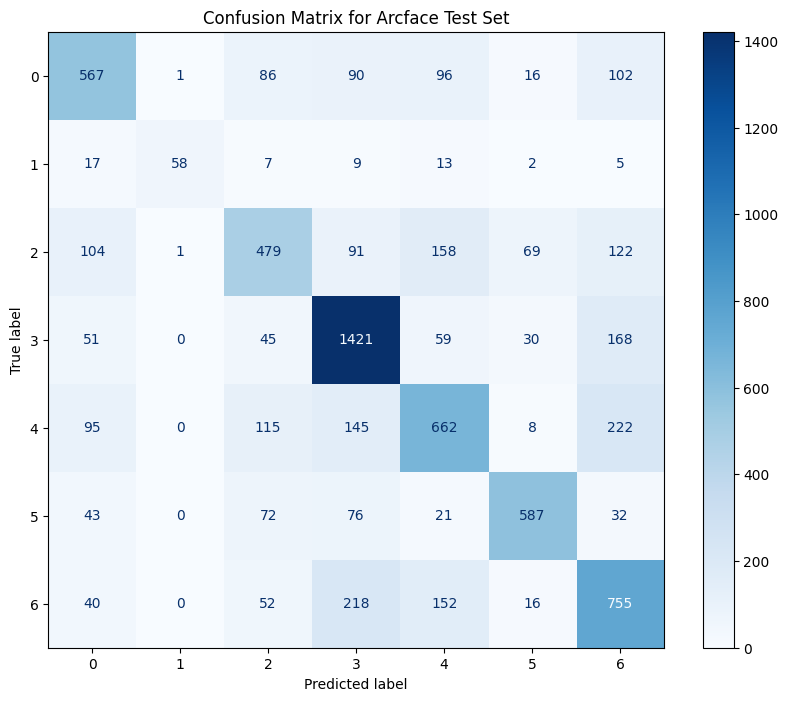

Confusion matrix generated and displayed for the test set.


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# 2. Get unique class labels for display
class_labels = sorted(np.unique(y_test))

# 3. Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# 4. Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix for Arcface Test Set")
plt.show()
print("Confusion matrix generated and displayed for the test set.")

## Generate Multi-Class ROC Curve for Test Set

### Subtask:
Generate and display a multi-class Receiver Operating Characteristic (ROC) curve for the predictions made on the Arcface test set. This will involve binarizing the `y_test` and `y_pred_test` labels and then calculating the ROC curve and AUC for each class, providing a visual representation of the classifier's performance at various threshold settings.

**Reasoning**:
The subtask requires generating and displaying a multi-class ROC curve. This involves binarizing the true labels, obtaining the model's decision function scores for each class, and then calculating and plotting the ROC curve and AUC for each class.



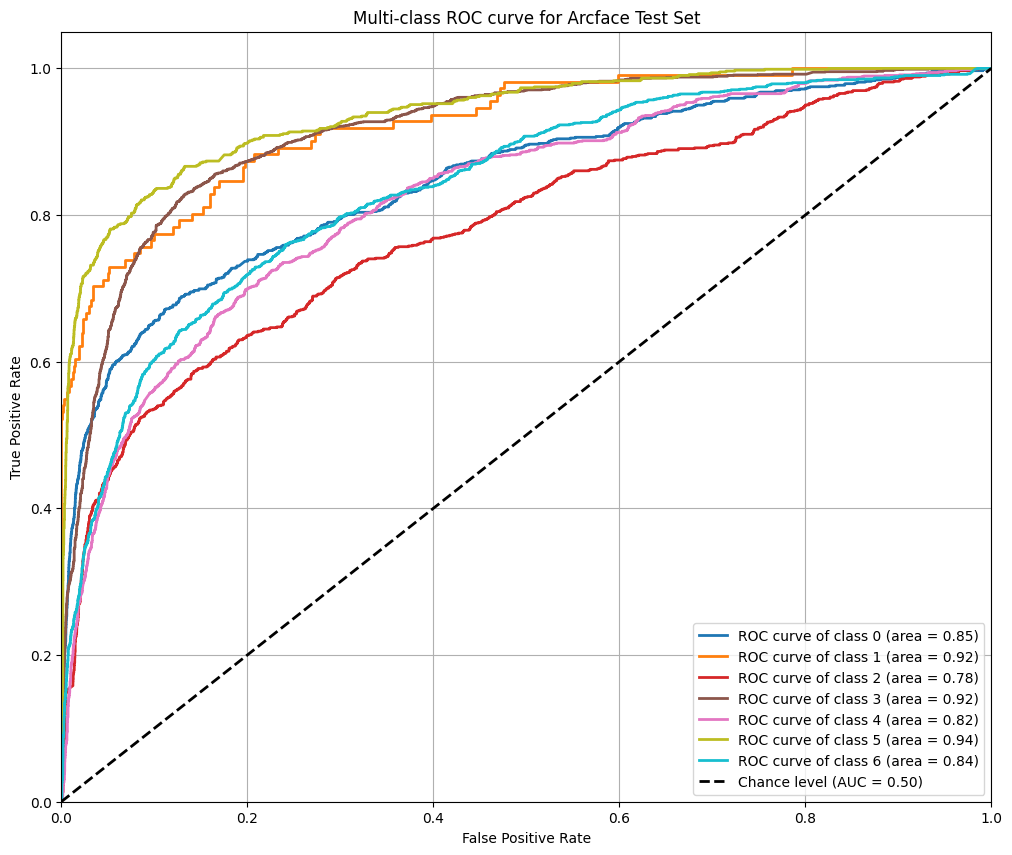

Multi-class ROC curves generated and displayed for the test set.


In [11]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. Binarize the true labels (y_test)
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
n_classes = y_test_binarized.shape[1]

# 2. Get decision function scores for the test set
# SVC does not directly provide predict_proba for all kernels, but decision_function is available
# We need to make sure the SVC was trained with `probability=True` if we want probabilities.
# However, `decision_function` can be used directly for ROC curves as well.
# Let's assume `best_model_arcface` is the fitted pipeline from previous steps.

# Check if best_model_arcface's SVC component has decision_function
# If it errors, it means the SVC was not configured for probability=True during fitting
# For simplicity and to avoid re-fitting, we will use decision_function as it is sufficient for ROC.

try:
    y_score = best_model_arcface.decision_function(X_test)
except AttributeError:
    print("Model does not have decision_function. Ensure SVC was fitted correctly or use predict_proba if available.")
    # Fallback or error handling for models without decision_function
    # For SVC without probability=True, decision_function is the standard output.
    # If the pipeline component was changed, this might need adjustment.

# If y_score is 1D (binary classification), reshape it
if y_score.ndim == 1:
    y_score = y_score.reshape(-1, 1)

# 3. Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot all ROC curves
plt.figure(figsize=(12, 10))
colors = plt.cm.get_cmap('tab10', n_classes) # Use a colormap for distinct colors
for i, color in zip(range(n_classes), colors.colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {label_binarizer.classes_[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance level (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC curve for Arcface Test Set')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("Multi-class ROC curves generated and displayed for the test set.")